# 1/3 (v6) — Dataset Collection: fixed scene, last-success anchor, no timestep input

Supersedes `1_collect_v5.ipynb`. Same 49-dim feature builder, same checkpoint
sources — three things changed, each addressing a specific issue found while
reviewing the v5 pipeline:

1. **Fixed scene, no domain randomization.** Object and goal position are
   sampled once and frozen (`RandomTaskSelectWrapper.sample_tasks_on_reset =
   False` + `set_task`) for every episode in this dataset. The fixed task is
   saved to `fixed_task.pkl` so notebook 2 and any later "can the arm learn
   the policy at all on one fixed scene" training run reuse the *exact* same
   scene instead of a fresh random one. All trajectory diversity now comes
   from checkpoint choice and stochastic action sampling, not from where the
   peg/goal happen to spawn.
2. **Zero point = end of trajectory, anchored on the *last* success frame,
   not the first.** v5 anchored on `success_step` (the first frame
   `info["success"]` went true) and then ran every episode out to the full
   500 steps, labelling everything after that 0. That produced a dataset
   that was 85% flat zero-labels (51409/60000 rows) and is fragile if
   success ever flickers (peg touches, slips, re-inserts). Here we roll out
   a short confirmation window past the first success, take the *last*
   confirmed success frame as the trajectory's end/zero-point, and stop
   collecting there — no long dead tail.
3. **No timestep/frame-index anywhere near the model.** The 49-dim feature
   vector was already state-only (raw obs + hand/peg/goal geometry); this
   version keeps it that way explicitly and also drops the old
   `seconds_remaining` / `timestamp_sec` columns from the saved dataset —
   the label is a plain step-count built by walking the episode *backward*
   from the last-success anchor, never a wall-clock quantity, and frame
   index is never concatenated into `X`.

Run top to bottom. Section 5 is a smoke test — check it before Section 6.

## 1. Imports and the shared feature builder

Identical to v5's feature builder — the model input stays state-only.

In [1]:
import gymnasium as gym
import metaworld
import numpy as np
import os, json, glob, pickle
import torch
from stable_baselines3 import SAC

In [2]:
# ============================================================
# SHARED FEATURE BUILDER — same as v5. No frame index / timestep / wall
# clock anywhere in here — model input is state only.
# ============================================================
HAND_POS_IDX = [0, 1, 2]
GRIPPER_IDX  = 3
PEG_POS_IDX  = [4, 5, 6]
GOAL_POS_IDX = [36, 37, 38]
GRIPPER_CLOSED_THRESHOLD = 0.6
FEATURE_DIM = 49

def build_features(obs):
    """39-dim raw obs -> 49-dim feature vector. No time information enters here.

    Columns:
       0-38  raw obs (unchanged)
      39-41  hand->peg vector
      42-44  peg->goal vector
         45  |hand->peg|
         46  |peg->goal|
         47  gripper openness
         48  holding flag (0/1)
    """
    obs = np.asarray(obs, dtype=np.float32)
    hand = obs[HAND_POS_IDX]
    peg  = obs[PEG_POS_IDX]
    goal = obs[GOAL_POS_IDX]
    gripper = obs[GRIPPER_IDX]

    hand_to_peg_vec = peg - hand
    peg_to_goal_vec = goal - peg
    hand_to_peg = np.linalg.norm(hand_to_peg_vec)
    peg_to_goal = np.linalg.norm(peg_to_goal_vec)
    holding = float(gripper < GRIPPER_CLOSED_THRESHOLD and hand_to_peg < 0.06)

    return np.concatenate([
        obs,
        hand_to_peg_vec,
        peg_to_goal_vec,
        [hand_to_peg, peg_to_goal, gripper, holding],
    ]).astype(np.float32)

In [3]:
TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

_probe = make_env(seed=0)
DT = getattr(_probe.unwrapped, "dt", _probe.unwrapped.model.opt.timestep)
RAW_OBS_DIM = _probe.observation_space.shape[0]
_probe.close()
print(f"DT={DT} (logged for reference only — never used as a feature or a label unit)")
print(f"raw obs dim={RAW_OBS_DIM}, feature dim={FEATURE_DIM}")

DT=0.0125 (logged for reference only — never used as a feature or a label unit)
raw obs dim=39, feature dim=49


D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")


## 2. Fix the scene

`gym.make("Meta-World/MT1", ...)` wraps the env in a `RandomTaskSelectWrapper`
that resamples a brand-new object/goal position **every reset** — that's why
two rollouts with the same `seed` still started from different peg
positions in v5. Here we reach into the wrapper chain once, turn that
resampling off, and pin a single task. The chosen task is pickled to disk
the first time this runs so re-running the notebook (or loading the scene
from notebook 2/3 later) reproduces the identical scene rather than picking
a new one.

In [4]:
OUTPUT_DIR = "./data/state_space_datasetV6"
os.makedirs(OUTPUT_DIR, exist_ok=True)
FIXED_TASK_PATH = os.path.join(OUTPUT_DIR, "fixed_task.pkl")

def find_wrapper(env, attr_name):
    """Walk the gym.Wrapper chain looking for the object that owns attr_name.
    Plain attribute access (env.foo) doesn't reliably forward through every
    wrapper in this stack (OrderEnforcing does not delegate), so walk `.env`
    explicitly instead of relying on __getattr__ delegation."""
    w = env
    while not hasattr(w, attr_name):
        if not hasattr(w, "env"):
            raise AttributeError(f"no wrapper in the chain exposes {attr_name!r}")
        w = w.env
    return w

def make_fixed_scene_env(render_mode=None, task_index=0):
    env = make_env(seed=0, render_mode=render_mode)
    task_wrapper = find_wrapper(env, "tasks")
    task_wrapper.toggle_sample_tasks_on_reset(False)  # stop resampling on reset

    if os.path.exists(FIXED_TASK_PATH):
        with open(FIXED_TASK_PATH, "rb") as f:
            fixed_task = pickle.load(f)
    else:
        fixed_task = task_wrapper.tasks[task_index]
        with open(FIXED_TASK_PATH, "wb") as f:
            pickle.dump(fixed_task, f)

    env.unwrapped.set_task(fixed_task)
    return env

In [5]:
# Sanity check: the scene must be identical across resets, regardless of seed.
_env = make_fixed_scene_env()
_obs_a, _ = _env.reset(seed=1)
_obs_b, _ = _env.reset(seed=999)
_env.close()
same_scene = np.allclose(_obs_a[PEG_POS_IDX + GOAL_POS_IDX], _obs_b[PEG_POS_IDX + GOAL_POS_IDX])
print(f"peg/goal position identical across resets: {same_scene}")
assert same_scene, "scene is not actually fixed — check RandomTaskSelectWrapper wiring"
print(f"peg pos: {_obs_a[PEG_POS_IDX]}")
print(f"goal pos: {_obs_a[GOAL_POS_IDX]}")
print(f"fixed task saved to: {os.path.abspath(FIXED_TASK_PATH)}")

peg/goal position identical across resets: True
peg pos: [0.11751744 0.6783546  0.03      ]
goal pos: [-0.28165585  0.63751751  0.13005779]
fixed task saved to: E:\@ML_Projects\Peg_insertion\data\state_space_datasetV6\fixed_task.pkl


D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


## 3. Checkpoint selection

Same early/mid/final spread as v5 — checkpoint diversity is now the main source of trajectory variety, since the scene no longer varies.

In [6]:
checkpoint_paths = sorted(
    glob.glob("./checkpoints/peg_insert_side/sac_peg_insert_*.zip"),
    key=lambda p: int("".join(ch for ch in os.path.basename(p) if ch.isdigit()) or 0))

selected_checkpoints = list(dict.fromkeys([
    checkpoint_paths[0],
    checkpoint_paths[len(checkpoint_paths)//2],
    checkpoint_paths[-1],
]))
print(f"{len(checkpoint_paths)} checkpoints found, using {len(selected_checkpoints)}:")
for p in selected_checkpoints:
    print("  ", os.path.basename(p))

8 checkpoints found, using 3:
   sac_peg_insert_final.zip
   sac_peg_insert_400000.zip
   sac_peg_insert_700000.zip


## 4. Collection + labelling

`collect_fixed_scene_episode` runs until a short confirmation window past the
**first** success frame, then stops — it does not run out to 500 steps.
It records every frame's success flag (not just the first), so
`build_reverse_labels` can anchor on the **last** True frame within that
window rather than assuming success is monotonic.

`build_reverse_labels` is the "end of trajectory = 0, walk backward" step:
start at the last-success frame (label 0) and count backward, one step at a
time, for every earlier frame. Anything at or after the anchor — including
the confirmation-buffer tail — is already-done and gets 0.

In [7]:
CONFIRM_BUFFER_FRAMES = 20  # ~0.25s at DT=0.0125 — long enough to catch a flicker, short enough to avoid a dead tail
MAX_STEPS = 500

def collect_fixed_scene_episode(model, env, deterministic, max_steps=MAX_STEPS,
                                 confirm_buffer=CONFIRM_BUFFER_FRAMES, seed=None):
    obs, _ = env.reset(seed=seed)
    obs_list, success_flags = [], []
    first_success = None
    frames_since_first_success = 0

    for t in range(max_steps):
        obs_list.append(obs.copy())
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        success_flags.append(bool(info.get(SUCCESS_KEY, 0)))

        if success_flags[-1] and first_success is None:
            first_success = t
        if first_success is not None:
            frames_since_first_success += 1
            if frames_since_first_success >= confirm_buffer:
                break
        if terminated or truncated:
            break

    if first_success is None:
        return None  # never succeeded — excluded, this dataset is successful-only

    return dict(obs_list=obs_list, success_flags=success_flags, first_success_idx=first_success)


def build_reverse_labels(success_flags):
    """Anchor on the LAST True frame, then walk backward assigning a step
    count. Frames at/after the anchor (already done) get 0."""
    n = len(success_flags)
    last_success_idx = max(i for i, s in enumerate(success_flags) if s)
    labels = np.zeros(n, dtype=np.float32)
    counter = 0
    for t in range(n - 1, -1, -1):          # walk the episode backward
        if t <= last_success_idx:
            labels[t] = counter
            counter += 1
        else:
            labels[t] = 0.0                 # confirmation-buffer tail: already done
    return labels, last_success_idx


def is_contiguous_success(success_flags, first_idx, last_idx):
    """True if success held for every frame in [first_idx, last_idx] — no
    drop-and-return. `last_idx - first_idx > 0` on its own does NOT mean
    flicker: we keep collecting for a fixed confirmation buffer past the
    first success, so last_idx is usually just first_idx + buffer - 1 even
    when success never wavered. Real flicker is a False *inside* that span."""
    return all(success_flags[first_idx:last_idx + 1])

## 5. Smoke test — check this before Section 6

In [8]:
_scene_env = make_fixed_scene_env()
_m = SAC.load(selected_checkpoints[-1])
_ep = collect_fixed_scene_episode(_m, _scene_env, deterministic=False, seed=0)
_scene_env.close()

assert _ep is not None, "smoke-test episode failed to succeed at all — investigate before Section 6"
_labels, _last_idx = build_reverse_labels(_ep["success_flags"])
_feat = build_features(_ep["obs_list"][0])
_contiguous = is_contiguous_success(_ep["success_flags"], _ep["first_success_idx"], _last_idx)

print(f"first success frame: {_ep['first_success_idx']}, last success frame (anchor): {_last_idx}")
print(f"confirmation window (anchor - first): {_last_idx - _ep['first_success_idx']} frames "
      f"— expected, this is just the buffer, not flicker")
print(f"success held continuously over that window (no flicker): {_contiguous}")
print(f"episode length collected: {len(_ep['obs_list'])} frames (v5 always collected 500)")
print(f"label at anchor: {_labels[_last_idx]} (expect 0), label at frame 0: {_labels[0]}")
print(f"feature vector shape: {_feat.shape} (expect (49,))")
assert _feat.shape[0] == FEATURE_DIM, "feature dim mismatch"
assert _labels[_last_idx] == 0, "anchor frame should be labelled 0"
print("OK — proceed to Section 6")

first success frame: 52, last success frame (anchor): 71
confirmation window (anchor - first): 19 frames — expected, this is just the buffer, not flicker
success held continuously over that window (no flicker): True
episode length collected: 72 frames (v5 always collected 500)
label at anchor: 0.0 (expect 0), label at frame 0: 71.0
feature vector shape: (49,) (expect (49,))
OK — proceed to Section 6


D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


## 6. Full collection

`deterministic=False` — with the scene fixed, a deterministic policy would
produce the bit-for-bit identical rollout every time, so stochastic action
sampling (seeded via `torch.manual_seed`, reproducible run-to-run) is the
source of trajectory diversity here instead of a new peg/goal position.

In [9]:
EPISODES_PER_CHECKPOINT = 40  # matches v5's total of 120 episodes for a fair before/after comparison
MAX_TRIES_PER_CKPT = EPISODES_PER_CHECKPOINT * 4

scene_env = make_fixed_scene_env()
episodes = []
episode_counter = 0

for ckpt in selected_checkpoints:
    ckpt_model = SAC.load(ckpt)
    tag = os.path.basename(ckpt)
    got, tries = 0, 0
    while got < EPISODES_PER_CHECKPOINT and tries < MAX_TRIES_PER_CKPT:
        torch.manual_seed(episode_counter)  # reproducible stochastic action sampling
        ep = collect_fixed_scene_episode(ckpt_model, scene_env, deterministic=False,
                                          seed=episode_counter)
        tries += 1
        episode_counter += 1
        if ep is not None:
            labels, last_idx = build_reverse_labels(ep["success_flags"])
            contiguous = is_contiguous_success(ep["success_flags"], ep["first_success_idx"], last_idx)
            episodes.append(dict(obs_list=ep["obs_list"], labels=labels,
                                  last_success_idx=last_idx,
                                  first_success_idx=ep["first_success_idx"],
                                  contiguous=contiguous,
                                  source_ckpt=tag))
            got += 1
    print(f"{tag}: {got}/{EPISODES_PER_CHECKPOINT} collected in {tries} attempts")

scene_env.close()

anchor_idxs = [ep["last_success_idx"] for ep in episodes]
ep_lengths = [len(ep["obs_list"]) for ep in episodes]
print(f"\nTotal: {len(episodes)} episodes")
print(f"anchor (last success) frame: min={min(anchor_idxs)}, max={max(anchor_idxs)}, "
      f"mean={np.mean(anchor_idxs):.1f}, std={np.std(anchor_idxs):.1f}")
print(f"episode length collected: min={min(ep_lengths)}, max={max(ep_lengths)}, "
      f"mean={np.mean(ep_lengths):.1f}  (v5 collected 500 for every episode)")

D:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")


sac_peg_insert_final.zip: 40/40 collected in 40 attempts


sac_peg_insert_400000.zip: 40/40 collected in 40 attempts


sac_peg_insert_700000.zip: 40/40 collected in 40 attempts

Total: 120 episodes
anchor (last success) frame: min=66, max=100, mean=77.8, std=12.8
episode length collected: min=67, max=101, mean=78.8  (v5 collected 500 for every episode)


## 7. Build feature rows + labels

In [10]:
records = []
for ep_idx, ep in enumerate(episodes):
    for t, obs in enumerate(ep["obs_list"]):
        records.append(dict(
            episode_idx=ep_idx,
            frame_idx=t,              # kept only for bookkeeping/plots — never fed to the model
            steps_remaining=float(ep["labels"][t]),
            features=build_features(obs),
        ))
print(f"Total rows: {len(records)}")
print(f"Avg frames/episode: {len(records)/len(episodes):.1f}")

Total rows: 9457
Avg frames/episode: 78.8


## 8. Save

In [11]:
X = np.stack([r["features"] for r in records]).astype(np.float32)
y_steps = np.array([r["steps_remaining"] for r in records], dtype=np.float32)
episode_ids = np.array([r["episode_idx"] for r in records], dtype=np.int32)
holding_flags = X[:, 48]

# No timestep/seconds column saved anywhere — steps_remaining is the only
# label, and it is purely an integer count from the reverse pass above.
np.savez(os.path.join(OUTPUT_DIR, "dataset.npz"),
         X=X, y_steps=y_steps, episode_ids=episode_ids, holding_flags=holding_flags)

confirm_gaps = [ep["last_success_idx"] - ep["first_success_idx"] for ep in episodes]
n_true_flicker = int(sum(not ep["contiguous"] for ep in episodes))
n_zero_rows = int((y_steps == 0).sum())

summary = dict(
    total_rows=int(len(records)),
    total_episodes=int(len(episodes)),
    feature_dim=int(X.shape[1]),
    dt_sec=float(DT),
    fixed_scene=True,
    fixed_task_path=os.path.abspath(FIXED_TASK_PATH),
    sources_used=sorted(set(ep["source_ckpt"] for ep in episodes)),
    checkpoint_diversity=len(set(ep["source_ckpt"] for ep in episodes)) > 1,
    label_anchor="last_success_frame",
    confirm_buffer_frames=CONFIRM_BUFFER_FRAMES,
    avg_frames_per_episode=round(len(records)/len(episodes), 1),
    anchor_frame_min=int(min(anchor_idxs)),
    anchor_frame_max=int(max(anchor_idxs)),
    anchor_frame_std=float(np.std(anchor_idxs)),
    true_flicker_episodes=n_true_flicker,
    confirm_gap_mean=float(np.mean(confirm_gaps)),
    confirm_gap_max=int(max(confirm_gaps)),
    zero_label_row_fraction=round(n_zero_rows / len(records), 4),
    holding_fraction=float(holding_flags.mean()),
)
with open(os.path.join(OUTPUT_DIR, "dataset_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "total_rows": 9457,
  "total_episodes": 120,
  "feature_dim": 49,
  "dt_sec": 0.0125,
  "fixed_scene": true,
  "fixed_task_path": "E:\\@ML_Projects\\Peg_insertion\\data\\state_space_datasetV6\\fixed_task.pkl",
  "sources_used": [
    "sac_peg_insert_400000.zip",
    "sac_peg_insert_700000.zip",
    "sac_peg_insert_final.zip"
  ],
  "checkpoint_diversity": true,
  "label_anchor": "last_success_frame",
  "confirm_buffer_frames": 20,
  "avg_frames_per_episode": 78.8,
  "anchor_frame_min": 66,
  "anchor_frame_max": 100,
  "anchor_frame_std": 12.834391190166452,
  "true_flicker_episodes": 0,
  "confirm_gap_mean": 19.0,
  "confirm_gap_max": 19,
  "zero_label_row_fraction": 0.0127,
  "holding_fraction": 0.6070635318756104
}

## 9. Evaluation & visualization

What to look for before treating this as ready for notebook 2:

- **Zero-label fraction should be far below v5's 85%.** A short
  confirmation tail means most rows carry real countdown signal.
- **True-flicker count should mostly be 0.** That counts episodes where
  success actually dropped and came back inside the confirmation window
  (not just "last != first", which is expected — that's the buffer). A
  nonzero true-flicker count is exactly the case anchoring on the *last*
  True frame protects against; if it's always 0 in practice for this task,
  that's fine — the anchor-on-last-success rule is a safety net, not
  something this task is expected to trigger often.
- **Anchor-frame spread should still be wide** even though the scene is
  fixed — that spread has to come entirely from checkpoint competence /
  stochastic action sampling now, so a narrow spread here means the dataset
  doesn't actually cover a range of "how close to done" states.

In [12]:
import matplotlib.pyplot as plt

print(f"zero-label rows: {n_zero_rows}/{len(records)} ({100*n_zero_rows/len(records):.1f}%)  "
      f"— v5 was 85.7% (51409/60000)")
print(f"true flicker (success dropped and returned inside the confirm window): "
      f"{summary['true_flicker_episodes']}/{len(episodes)}")
print(f"confirmation gap (anchor - first success, NOT flicker): "
      f"mean={summary['confirm_gap_mean']:.1f}, max={summary['confirm_gap_max']} frames")

for ep_idx, ep in enumerate(episodes[:5]):
    flag = "  <-- TRUE FLICKER" if not ep["contiguous"] else ""
    print(f"  ep {ep_idx} ({ep['source_ckpt']}): first={ep['first_success_idx']}, "
          f"last={ep['last_success_idx']}, len={len(ep['obs_list'])}{flag}")

zero-label rows: 120/9457 (1.3%)  — v5 was 85.7% (51409/60000)
true flicker (success dropped and returned inside the confirm window): 0/120
confirmation gap (anchor - first success, NOT flicker): mean=19.0, max=19 frames
  ep 0 (sac_peg_insert_final.zip): first=48, last=67, len=68
  ep 1 (sac_peg_insert_final.zip): first=48, last=67, len=68
  ep 2 (sac_peg_insert_final.zip): first=48, last=67, len=68
  ep 3 (sac_peg_insert_final.zip): first=47, last=66, len=67
  ep 4 (sac_peg_insert_final.zip): first=47, last=66, len=67


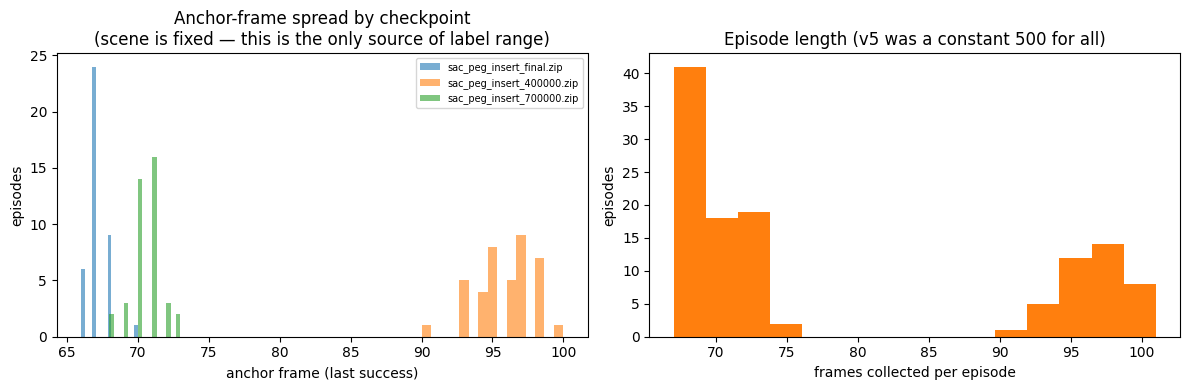

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

by_source = {}
for ep in episodes:
    by_source.setdefault(ep["source_ckpt"], []).append(ep["last_success_idx"])
for tag, vals in by_source.items():
    ax[0].hist(vals, bins=15, alpha=0.6, label=tag)
ax[0].set_xlabel("anchor frame (last success)"); ax[0].set_ylabel("episodes")
ax[0].set_title("Anchor-frame spread by checkpoint\n(scene is fixed — this is the only source of label range)")
ax[0].legend(fontsize=7)

ep_lens = [len(ep["obs_list"]) for ep in episodes]
ax[1].hist(ep_lens, bins=15, color="tab:orange")
ax[1].set_xlabel("frames collected per episode"); ax[1].set_ylabel("episodes")
ax[1].set_title("Episode length (v5 was a constant 500 for all)")
plt.tight_layout(); plt.show()

### Grasp/holding validation (same check as v5)

In [14]:
grasp_frames, multi, missing = [], 0, 0
for ep in np.unique(episode_ids):
    h = holding_flags[episode_ids == ep]
    onsets = np.where(np.diff(h) > 0)[0]
    if len(onsets) == 0:
        missing += 1
    else:
        grasp_frames.append(onsets[0])
        if len(onsets) > 1:
            multi += 1

grasp_frames = np.array(grasp_frames)
print(f"detected: {len(grasp_frames)}/{len(np.unique(episode_ids))}, "
      f"no grasp: {missing}, multiple transitions: {multi}")
print(f"grasp frame: mean={grasp_frames.mean():.1f}, min={grasp_frames.min()}, max={grasp_frames.max()}")
print(f"holding=1 fraction: {holding_flags.mean():.1%}")

detected: 120/120, no grasp: 0, multiple transitions: 0
grasp frame: mean=29.9, min=25, max=43
holding=1 fraction: 60.7%


### Sample label curves — label should fall to 0 exactly at the anchor

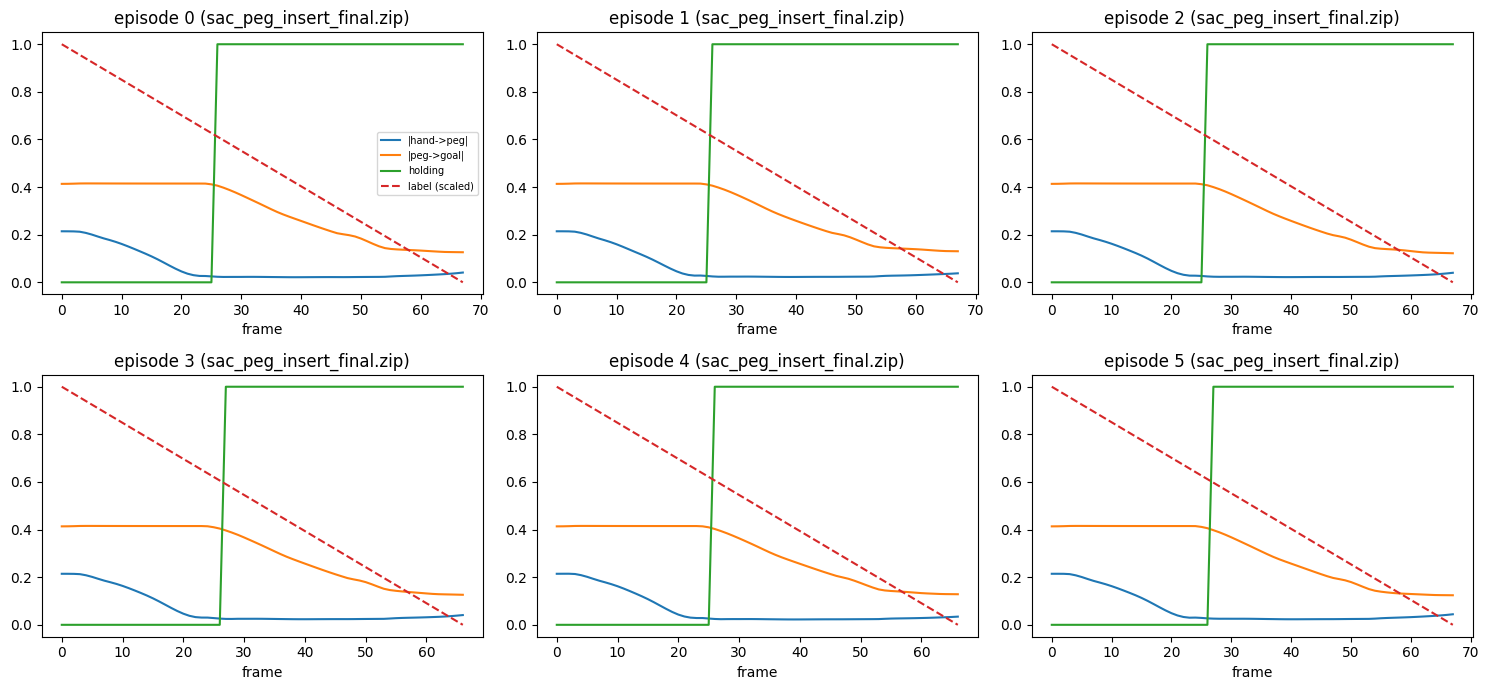

In [15]:
sample_eps = sorted(set(episode_ids.tolist()))[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, ep_idx in zip(axes.flat, sample_eps):
    m = episode_ids == ep_idx
    ax.plot(X[m, 45], label="|hand->peg|")
    ax.plot(X[m, 46], label="|peg->goal|")
    ax.plot(X[m, 48], label="holding")
    denom = max(y_steps[m].max(), 1)
    ax.plot(y_steps[m] / denom, "--", label="label (scaled)")
    ax.set_title(f"episode {ep_idx} ({episodes[ep_idx]['source_ckpt']})")
    ax.set_xlabel("frame")
axes.flat[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

### Does the engineered distance actually rank with the label?

Spearman correlation between `|peg->goal|` and the label, pre-anchor rows only (post-anchor rows are all 0 by construction and would just dilute this).

In [16]:
from scipy.stats import spearmanr

pre_anchor = y_steps > 0
rho, _ = spearmanr(X[pre_anchor, 46], y_steps[pre_anchor])
print(f"spearman(|peg->goal|, label) on pre-anchor rows: {rho:.3f}  "
      f"(should be strongly positive — farther from goal should mean more steps remaining)")

spearman(|peg->goal|, label) on pre-anchor rows: 0.936  (should be strongly positive — farther from goal should mean more steps remaining)


## 10. Reminders for what comes next

- **`fixed_task.pkl` is the scene contract.** Any later stage — training a
  time2success model on this data, or the "does the arm learn the policy at
  all on a single fixed scene, no randomization" sanity-check training run
  — should load this same file (`env.unwrapped.set_task(pickle.load(...))`
  after `toggle_sample_tasks_on_reset(False)`) rather than sampling a new
  scene. Comparisons across stages are only meaningful if the scene didn't
  quietly change underneath them.
- **Still successful-only, still from a handful of checkpoints on one
  scene.** This dataset answers "does the model track progress toward *this*
  goal correctly," not "does it generalize across goals" — that's a
  deliberately different, narrower question than v5 was aimed at, matching
  the fixed-scene policy-learning check this feeds into.
- **If the zero-label fraction or flicker count above look off**, revisit
  `CONFIRM_BUFFER_FRAMES` before moving to notebook 2 — it's the one knob
  controlling both.